# Ingeniería de Características — Dataset FDIC RIS

## Introducción

Una vez completado el análisis exploratorio del dataset __RIS__ en `01_eda.ipynb`, este notebook aborda la selección de variables y construcción de los paneles finales que servirán como datos de ingestión para el pipeline híbrido de ML. El reto principal a la hora de trabajar con este dataset es su alta dimensionalidad, ya que a la hora de crear el panel tabular de datos para `TabPFN`, si unieramos todos los paneles actuales de `FTS`, `CDI`, `RAT`, tendriamos un panel tabular con 4719 columnas, lo cual, si tenemos en cuenta las capacidades de `TabPFN v2.6`, que es el modelo que empleamos, escala hasta 2,000 features/columnas, luego el modelo estaria entrando en una zona donde no estaría cubriendo el dataset (panel tabular) completo de forma directa y tambien afecta a la interpretabilidad posterior con __SHAP__. Del mismo modo, unir las dos bases de datos de `MERG`y `STRU`, nos daria una base de datos (panel de nodos) con 183 columnas, lo cual tambien es intratable.

 Luego sobre los dataset tenemos que realizar dos preprocesamientos de datos:

> __Ingenieria de caracteristicas__: La selección de columnas relevantes dentro de `FTS`, `CDI`, `RAT`, `STRU` y `MERG`.

> __Ingeniería de datos__: La limpieza de datos, construcción de los paneles temporal y de nodos.

El proceso de reducción se articula en tres capas metodológicas:

1. **Capa A — Filtros estadísticos**: eliminación de variables no informativas por NaN, varianza cero o nombre duplicado
2. **Capa B — Marco teórico CAMELS**: mapeo automático de variables supervivientes al framework regulatorio bancario
3. **Capa C — Validación empírica**: correlación punto-biserial con el evento de quiebra para confirmar poder discriminativo

El orden a seguir no es arbitrario, ya que primero se eliminan variables técnicamente inutilizables, luego se aplica el criterio teórico sobre las restantes, y finalmente se valida empíricamente la selección. El resultado de este procedimiento nos permite crear tres paneles de datos (bases de datos filtradas para una mejor interpretabilidad), los cuales seran usados en distintas etapas del pipeline del modelo hibrido.

In [2]:
from pathlib import Path
from dotenv import load_dotenv
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib


project_root = Path.cwd().parents[0]
load_dotenv(project_root / ".env")
sys.path.insert(0, str(project_root))

from src.data.loader import get_quarters, load_quarter, load_failures
from src.utils.config import PROCESSED_DIR

quarters = get_quarters()
print(f"Trimestres disponibles: {len(quarters)}")

Trimestres disponibles: 40


La forma teorica de abordar esta problematica es mediante un preprocesado en capas.


__Capa A — Filtros estadísticos__

Sobre todas la variables que tenemos en las bases de datos, aplicamos una serie de filtros estadisticos:

>- Eliminar variables con mas de unX% de NaN
>- Eliminar variables con varianza cuasi-cero
>- Eliminar variables con correlación >0.95 entre sí (VIF o matriz de correlación)

Esto lo hacemos a modo de limpieza estadistica inicial para trabajar solo con datos relevantes (no redundantes) o que no sea inutilizables debido a que faltan demasiados datos en dichas variables

__Capa B — Marco teórico CAMELS__

`CAMELS` es un marco de evaluación bancaria que organiza el análisis del riesgo y la solidez de una entidad en seis dimensiones: __Capital adequacy__, __Asset quality__, __Management__, __Earnings__, __Liquidity__ y __Sensitivity to market risk__. El valor de esta evaluación ofrece una estructura reconocible y trazable para seleccionar variables financieras con significado económico y regulatorio. La literatura sobre early warning systems y diagnóstico de fragilidad bancaria ha utilizado de forma recurrente indicadores alineados con `CAMELS` para anticipar deterioro, insolvencia o problemas de supervisión. En ese sentido, mapear variables del dataset a estas dimensiones no es una decisión arbitraria, sino una forma de anclar la ingeniería de variables en un marco interpretativo consolidado.

Usar `CAMELS` permite convertir un conjunto amplio de variables bancarias en bloques conceptuales más manejables. Por ejemplo, ratios de capital se asocian con __C__, indicadores de morosidad o calidad de activos con __A__, métricas de eficiencia con __M__, rentabilidad con __E__, liquidez con __L__ y exposición a tipos de interés o mercado con __S__. Esa agrupación facilita tanto la selección de features como la discusión de resultados, porque permiten explicar qué dimensión del perfil bancario está impulsando el riesgo predicho.

En este trabajo adoptamos `CAMELS` como marco teórico para estructurar la selección de variables bancarias ya que ha sido ampliamente utilizado en la literatura de solvencia bancaria y sistemas de alerta temprana.

__Capa C — Importancia estadística con el target__
Realizamos el calculo de la correlación `punto-biserial` de cada variable candidata con el evento de quiebra de la base de datos `failures`. Las variables que selecionamos finalmente son las que tienen mayor poder discriminativo estadístico.

Cargamos las cinco bases de datos completas construidas en el notebook anterior. Verificamos _shapes_ y `CERT` únicos para confirmar consistencia.

In [2]:
# recuperamos las bases de datos completas
panels = {}
for name in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    panels[name] = pd.read_parquet(PROCESSED_DIR / f"panel_{name}.parquet")
    print(f"{name}: {panels[name].shape}")

FTS: (206129, 3370)
CDI: (206129, 1098)
RAT: (206129, 254)
MERG: (1100520, 62)
STRU: (219576, 123)


A la hora de definir el umbral con el que vamos a trabajar para eliminar variables con alto porcentaje de `NaN`, no existe un valor definido claro, pero si tenemos en cuenta ciertos aspectos, en literatura de riesgo financiero y banking, el `50%` es el umbral más usado en papers de early warning systems bancarios (Demyanyk & Hasan, 2010; Betz et al., 2014) ya que en datos regulatorios bancarios, muchos campos son opcionales según el tipo de institución, lo cual implica que un `NaN` no siempre significa dato faltante, sino que esa variable no aplica a ese banco. En machine learning tabular general:

>80-90% es más permisivo — se usa cuando los NaN son aleatorios y no estructurales
>20-30% es muy estricto — se usa cuando tienes muchos datos y puedes permitirte perder variables

Luego tenemos que nuestro dataset de `RIS` tiene `NaN` estructurales, ya que recopila datos de instituciones y bancos  pequeños que no reportan variables de derivados financieros complejos, no porque le falte el dato sino porque no opera con ellos. Luego realizamos un breve estudio sobre varios umbrales para evaluar cual es el mejor para nuestros datos.

In [3]:
print(f"{'Umbral':<10} {'FTS':>8} {'CDI':>8} {'RAT':>8} {'MERG':>8} {'STRU':>8}")
print("-" * 50)
for threshold in [0.3, 0.5, 0.6, 0.7, 0.8]:
    row = f"{threshold*100:.0f}%{'':<7}"
    for name in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
        # Columnas que SE ELIMINAN por tener más NaN que el umbral
        n_eliminadas = (panels[name].isnull().mean() > threshold).sum()
        row += f"{n_eliminadas:>8}"
    print(row)



Umbral          FTS      CDI      RAT     MERG     STRU
--------------------------------------------------
30%           1892     354      43       2       9
50%           1793     341      35       2       7
60%           1724     325      30       2       7
70%           1231     265      26       2       7
80%           1077     252      24       1       5


Como vemos, los paneles `MERG` y `STRU` son bastante insensibles a la eliminación de variables `NaN`, debido a que son paneles con menos variables que los demás y a la naturaleza propia de los datos que almacenan, que son de caracter estructural más que numerico.

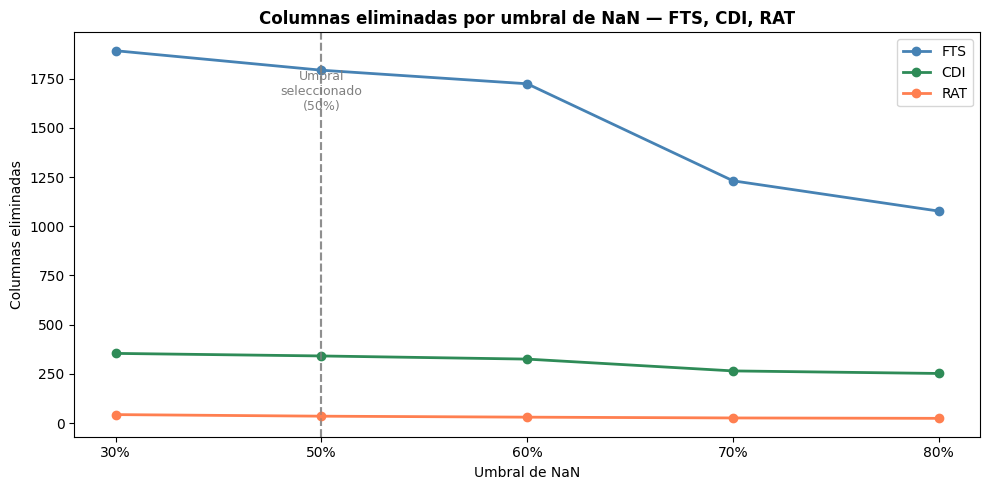


Decisión: umbral 50% — equilibrio entre completitud y eliminación de variables sparse
Justificación: salto moderado 30%→50% vs salto grande 50%→80% en FTS (+718 columnas)


In [4]:
# Visualización del análisis de umbral
thresholds = [0.3, 0.5, 0.6, 0.7, 0.8]
bases = ['FTS', 'CDI', 'RAT']  # solo las relevantes para el panel tabular TabPFN

results_threshold = {ft: [] for ft in bases}
for threshold in thresholds:
    for name in bases:
        n_eliminadas = (panels[name].isnull().mean() > threshold).sum()
        results_threshold[name].append(n_eliminadas)

fig, ax = plt.subplots(figsize=(10, 5))
x = [f"{int(t*100)}%" for t in thresholds]
colors = ['steelblue', 'seagreen', 'coral']

for i, (name, color) in enumerate(zip(bases, colors)):
    ax.plot(x, results_threshold[name], marker='o', 
            label=name, color=color, linewidth=2)
    # Marcar el umbral elegido
    idx_50 = thresholds.index(0.5)
    ax.axvline(x=idx_50, color='gray', linestyle='--', alpha=0.5)

ax.set_title('Columnas eliminadas por umbral de NaN — FTS, CDI, RAT', fontweight='bold')
ax.set_xlabel('Umbral de NaN')
ax.set_ylabel('Columnas eliminadas')
ax.legend()
ax.annotate('Umbral\nseleccionado\n(50%)', xy=(idx_50, ax.get_ylim()[1]*0.8),
             ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'fe_nan_threshold.png', dpi=150)
plt.show()

print("\nDecisión: umbral 50% — equilibrio entre completitud y eliminación de variables sparse")
print("Justificación: salto moderado 30%→50% vs salto grande 50%→80% en FTS (+718 columnas)")

En el resto de paneles a excepción de `FTS`, vemos que el cambio en los umbrales no es muy agresivo, en `CDI` pasar de un umbral de 30% a 80% solo elimina 103 columnas más. Donde se ve más el salto es en `FTS` ya que de 60% al 70% hay un salto de 483 columnas lo que indica que hay un bloque grande de columnas con un 60% minimo y un 70% máximo de `NaN` en sus datos, que probablemente sean variables opcionales que muy pocos bancos reportan.

Una vez definido el umbral a emplear, aplicamos tres filtros secuenciales sobre cada panel:
1. Eliminar columnas con más del 50% de NaN
2. Eliminar columnas numéricas con varianza cero
3. Eliminar nombres de columna duplicados

In [5]:
def clean_panel(df: pd.DataFrame, name: str, 
                nan_threshold: float,
                variance_threshold: float = 0.0) -> pd.DataFrame:
    """
    Limpieza estadística en tres pasos:
    1. Elimina columnas con más del nan_threshold% de NaN
    2. Elimina columnas numéricas con varianza cero o cuasi-cero
    3. Elimina columnas duplicadas
    """
    original_cols = df.shape[1]
    
    # Paso 1 — Filtro NaN
    nan_rate = df.isnull().mean()
    cols_nan = nan_rate[nan_rate > nan_threshold].index.tolist()
    df = df.drop(columns=cols_nan)
    print(f"{name} | Paso 1 NaN >{nan_threshold*100:.0f}%: "
          f"-{len(cols_nan)} cols → {df.shape[1]} restantes")
    
    # Paso 2 — Filtro varianza cero (solo numéricas)
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    low_var = [c for c in num_cols if df[c].var() <= variance_threshold]
    df = df.drop(columns=low_var)
    print(f"{name} | Paso 2 varianza=0: "
          f"-{len(low_var)} cols → {df.shape[1]} restantes")
    
    # Paso 3 — Duplicadas por nombre (evita transposición)
    dupes = df.columns.duplicated().sum()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"{name} | Paso 3 nombres duplicados: "
          f"-{dupes} cols → {df.shape[1]} restantes")
    
    total = original_cols - df.shape[1]
    print(f"{name} | Total eliminadas: {total} de {original_cols} "
          f"({total/original_cols*100:.1f}%)\n")
    return df

In [6]:

THRESHOLD = 0.5  # umbral elegido tras el análisis

panels_clean = {}
for name, df in panels.items():
    print(f"{'='*45}")
    print(f"Limpiando {name}...")
    panels_clean[name] = clean_panel(df, name, nan_threshold=THRESHOLD)
    output = PROCESSED_DIR / f"panel_{name}_clean.parquet"
    panels_clean[name].to_parquet(output, index=False)
    print(f"Guardado: {output}")

print(f"\n{'Base':<8} {'Original':>10} {'Limpio':>10} {'Reducción':>12}")
print("-" * 42)
for name in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    orig = panels[name].shape[1]
    clean = panels_clean[name].shape[1]
    pct = (orig - clean) / orig * 100
    print(f"{name:<8} {orig:>10} {clean:>10} {pct:>11.1f}%")

Limpiando FTS...
FTS | Paso 1 NaN >50%: -1793 cols → 1577 restantes
FTS | Paso 2 varianza=0: -20 cols → 1557 restantes
FTS | Paso 3 nombres duplicados: -0 cols → 1557 restantes
FTS | Total eliminadas: 1813 de 3370 (53.8%)

Guardado: D:\financial_risk_data\processed\panel_FTS_clean.parquet
Limpiando CDI...
CDI | Paso 1 NaN >50%: -341 cols → 757 restantes
CDI | Paso 2 varianza=0: -6 cols → 751 restantes
CDI | Paso 3 nombres duplicados: -0 cols → 751 restantes
CDI | Total eliminadas: 347 de 1098 (31.6%)

Guardado: D:\financial_risk_data\processed\panel_CDI_clean.parquet
Limpiando RAT...
RAT | Paso 1 NaN >50%: -35 cols → 219 restantes
RAT | Paso 2 varianza=0: -0 cols → 219 restantes
RAT | Paso 3 nombres duplicados: -0 cols → 219 restantes
RAT | Total eliminadas: 35 de 254 (13.8%)

Guardado: D:\financial_risk_data\processed\panel_RAT_clean.parquet
Limpiando MERG...
MERG | Paso 1 NaN >50%: -2 cols → 60 restantes
MERG | Paso 2 varianza=0: -0 cols → 60 restantes
MERG | Paso 3 nombres duplicado

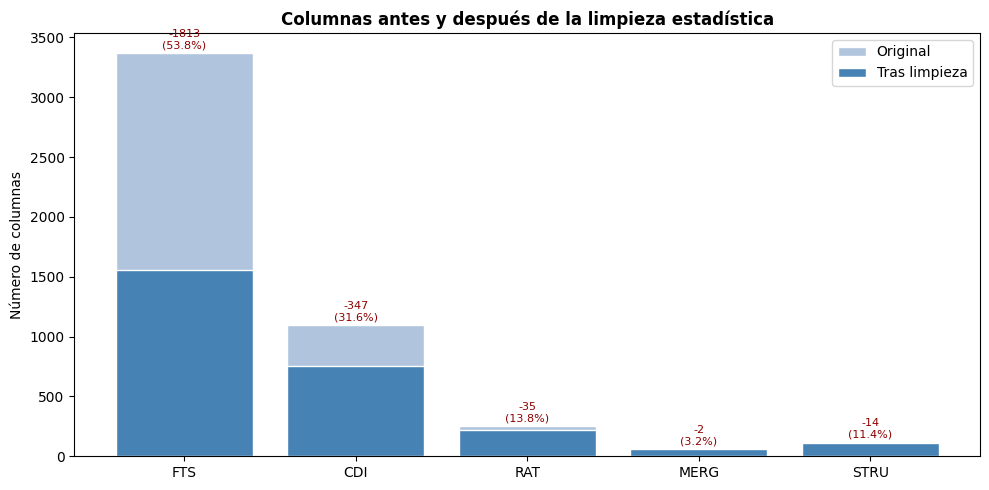

In [7]:
# Visualización del resultado de limpieza
fig, ax = plt.subplots(figsize=(10, 5))
bases_all = ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']
originales = [panels[n].shape[1] for n in bases_all]
limpios = [panels_clean[n].shape[1] for n in bases_all]
reduccion = [o - l for o, l in zip(originales, limpios)]

x = range(len(bases_all))
bars1 = ax.bar(x, originales, label='Original', color='lightsteelblue', edgecolor='white')
bars2 = ax.bar(x, limpios, label='Tras limpieza', color='steelblue', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(bases_all)
ax.set_title('Columnas antes y después de la limpieza estadística', fontweight='bold')
ax.set_ylabel('Número de columnas')
ax.legend()

for i, (orig, limp, red) in enumerate(zip(originales, limpios, reduccion)):
    ax.text(i, orig + 20, f'-{red}\n({red/orig*100:.1f}%)', 
            ha='center', va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'fe_cleaning_result.png', dpi=150)
plt.show()

La grafica y la tabla indican que, de entre los paneles con variables numericas, `RAT` es el más limpio, solo el 13.8% eliminado y varianza cero en ninguna columna. Lo cual nos confirma que es la base de datos más sólida para crear el panel tabular, ya que casi todas sus variables son informativas. `FTS` pierde el 54.7% debido posiblemente a que es el panel más amplio y con muchas variables opcionales por tipo de institución. Los 36 de varianza cero son probablemente flags binarios que nunca cambiaron en el periodo. `CDI` 31.9% presenta una reducción moderada, coherente con ser un panel de variables derivadas.

`MERG` y `STRU` casi intactos ya que son paneles que contienen datos estructurales.

El siguiente paso es hacer el estudio `CAMELS` sobre los paneles procesados de `FTS`, `RAT` y `CDI` que seran las bases de datos con las que construiremos nuestros datos tabulares para `TabPFN`. La idea es quedarse con las variables más relevantes siguiendo el estudio `CAMELS`, que es el framework oficial que usan los reguladores bancarios estadounidenses (__FDIC__, __Fed__, __OCC__) para evaluar la salud de un banco. Cada letra representa una dimensión de riesgo, la cual responde a las siguientes preguntas:

- `C` — Capital Adequacy: ¿tiene el banco suficiente capital para absorber pérdidas?

- `A` — Asset Quality: ¿qué porcentaje de sus préstamos son problemáticos?

- `M` — Management: ¿opera el banco de forma eficiente?

- `E` — Earnings: ¿es rentable?

- `L` — Liquidity: ¿puede hacer frente a sus obligaciones a corto plazo?

- `S` — Sensitivity to market risk: ¿cómo le afectan los cambios en tipos de interés y mercados?

Como ya hemos visto, tenemos un diccionario, faciliatdo por el `FDIC`, que no explica brevemente el significado de cada variable de cada base de datos, luego para seleccionar las variables restantes a la limpieza más relevantes lo que hacemos es un mapeo por _keywords_ en las descripciones del diccionario oficial __FDIC__. Usamos las siguientes _keywords_ ya que cada componente `CAMELS` tiene un significado financiero concreto, y las _keywords_ son los términos técnicos que la `FDIC` usa en las descripciones de las variables.

- `C` — __Capital__: Las variables de capital se describen con términos como `CAPITAL`, `EQUITY`, `TIER` (Tier 1, Tier 2 son los niveles de capital regulatorio Basel III), `RBC` (Risk Based Capital), `LEVERAGE` y `TANGIBLE` (capital tangible, sin intangibles como goodwill).

- `A` — __Asset Quality__: La calidad de activos se mide por morosidad y pérdidas. Los términos del diccionario son `NONCURR` (noncurrent = préstamos impagados), `CHARGE-OFF` (préstamos dados por perdidos), `NONPERFORM` (nonperforming assets), `PAST DUE` (vencidos), `LOAN LOSS` (pérdidas en préstamos), `ALLOWANCE` (provisiones) y `PROVISION`.

- `M` — __Management__: La eficiencia operativa se describe con `EFFICIENCY` (el efficiency ratio es la métrica estándar — gastos operativos / ingresos), `EXPENSE`, `OVERHEAD`, `EMPLOYEE` (productividad por empleado).

- `E` — __Earnings__: La rentabilidad usa `INCOME`, `RETURN`, `PROFIT`, `EARNINGS`, `REVENUE`, `MARGIN` (net interest margin) y directamente `ROA`, `ROE`.

- `L` — __Liquidity__: La liquidez se mide por la estructura de financiación, `DEPOSIT`, `LIQUID`, `CASH`, `BORROW`, `FUNDING` y ratios como loans/deposits.

- `S` — __Sensitivity__: El riesgo de mercado usa `MARKET`, `TRADING`, `DERIVATIVE`, `RATE` (sensibilidad a tipos de interés), `FOREIGN` (riesgo divisa), `SECURITIES` y `HEDGE`.

Las _keywords_ no son una elección arbitraria sino que son los términos que aparecen literalmente en el diccionario oficial de la FDIC para describir las variables que se encuentran en las diferentes bases de datos y que nosotros relacionamos a cada dimensión de `CAMELS`, para tener una base solida de elección.

In [8]:
import csv
# Cargar diccionarios
def load_dict(path):
    with open(path, encoding='utf-8') as f:
        reader = csv.DictReader(f)
        return {r['RIS Name']: r['Description'] for r in reader}

# Rutas a los diccionarios (en tu máquina local)
# Necesitas tener los CSV del diccionario accesibles
# Si los tienes en el repo, ajusta la ruta
dict_rat = load_dict(project_root / "docs" / "RAT.csv")
dict_fts = load_dict(project_root / "docs" / "FTS.csv")
dict_cdi = load_dict(project_root / "docs" / "CDI.csv")

# Keywords por componente CAMELS
CAMELS_KEYWORDS = {
    "C": ["CAPITAL", "EQUITY", "TIER", "RBC", "LEVERAGE", "TANGIBLE", "SOLVENCY"],
    "A": ["NONCURR", "CHARGE-OFF", "NONPERFORM", "PAST DUE", 
          "LOAN LOSS", "ALLOWANCE", "PROVISION", "DELINQ"],
    "M": ["EFFICIENCY", "EXPENSE", "OVERHEAD", "EMPLOYEE", 
          "SALARY", "NONINTEREST EXP"],
    "E": ["INCOME", "RETURN", "PROFIT", "EARNINGS", 
          "REVENUE", "MARGIN", "ROA", "ROE"],
    "L": ["DEPOSIT", "LIQUID", "CASH", "BORROW", 
          "FUNDING", "ASSET/DEP", "LOANS/DEP"],
    "S": ["MARKET", "TRADING", "DERIVATIVE", "RATE", 
          "FOREIGN", "SECURITIES", "HEDGE"],
}

def map_to_camels(description: str) -> str:
    """Asigna un componente CAMELS a una variable por su descripción."""
    desc_upper = description.upper()
    matches = []
    for component, keywords in CAMELS_KEYWORDS.items():
        if any(k in desc_upper for k in keywords):
            matches.append(component)
    if len(matches) == 1:
        return matches[0]
    elif len(matches) > 1:
        return matches[0]  # primer match gana — orden CAMELS
    return "UNASSIGNED"

# Cargar columnas supervivientes de cada panel limpio
rat_clean = pd.read_parquet(PROCESSED_DIR / "panel_RAT_clean.parquet")
fts_clean = pd.read_parquet(PROCESSED_DIR / "panel_FTS_clean.parquet")
cdi_clean = pd.read_parquet(PROCESSED_DIR / "panel_CDI_clean.parquet")

# Construir mapping completo
records = []
for source, clean_df, dictionary in [
    ("RAT", rat_clean, dict_rat),
    ("FTS", fts_clean, dict_fts),
    ("CDI", cdi_clean, dict_cdi),
]:
    nan_rates = clean_df.isnull().mean()
    for col in clean_df.columns:
        if col in ["CERT", "period", "CALLYM", "CALLYMD", "REPDTE"]:
            continue  # skip identificadores
        desc = dictionary.get(col, "")
        component = map_to_camels(desc)
        records.append({
            "variable":  col,
            "source":    source,
            "description": desc,
            "camels":    component,
            "nan_rate":  round(nan_rates[col], 4),
        })

df_mapping = pd.DataFrame(records)

# Guardar
output_path = project_root / "docs" / "camels_mapping.csv"
df_mapping.to_csv(output_path, index=False)
print(f"Mapping guardado: {output_path}")
print(f"\nTotal variables mapeadas: {len(df_mapping)}")
print(f"\nDistribución por componente:")
print(df_mapping['camels'].value_counts())
print(f"\nDistribución por fuente:")
print(df_mapping.groupby(['source', 'camels']).size().unstack(fill_value=0))

Mapping guardado: c:\dev\tfm-financial_risk\docs\camels_mapping.csv

Total variables mapeadas: 2512

Distribución por componente:
camels
UNASSIGNED    1877
E              161
S              128
C              115
L              102
A               73
M               56
Name: count, dtype: int64

Distribución por fuente:
camels   A   C   E   L   M    S  UNASSIGNED
source                                     
CDI     16  25  83  39  26   23         534
FTS     41  61  49  54  16  101        1230
RAT     16  29  29   9  14    4         113


Las variables sin asignación clara quedan como `UNASSIGNED` y se descartan.

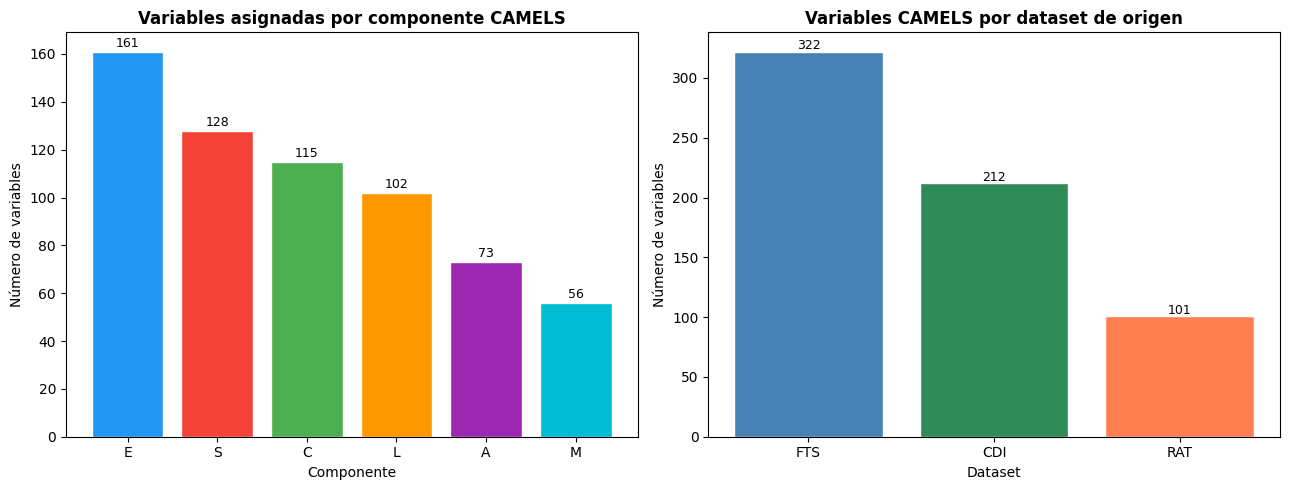

Variables asignadas a CAMELS: 635
Variables UNASSIGNED (descartadas): 1877


In [3]:
# Distribución del mapeo CAMELS
df_mapping = pd.read_csv(project_root / "docs" / "camels_mapping.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por componente
camels_dist = df_mapping[df_mapping['camels'] != 'UNASSIGNED']['camels'].value_counts()
colors_camels = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4']
axes[0].bar(camels_dist.index, camels_dist.values, 
            color=colors_camels, edgecolor='white')
axes[0].set_title('Variables asignadas por componente CAMELS', fontweight='bold')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Número de variables')
for i, (idx, val) in enumerate(camels_dist.items()):
    axes[0].text(i, val + 2, str(val), ha='center', fontsize=9)

# Por fuente
source_dist = df_mapping[df_mapping['camels'] != 'UNASSIGNED']['source'].value_counts()
axes[1].bar(source_dist.index, source_dist.values,
            color=['steelblue','seagreen','coral'], edgecolor='white')
axes[1].set_title('Variables CAMELS por dataset de origen', fontweight='bold')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Número de variables')
for i, (idx, val) in enumerate(source_dist.items()):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'fe_camels_mapping.png', dpi=150)
plt.show()

print(f"Variables asignadas a CAMELS: {(df_mapping['camels'] != 'UNASSIGNED').sum()}")
print(f"Variables UNASSIGNED (descartadas): {(df_mapping['camels'] == 'UNASSIGNED').sum()}")

Explicitamente las variables seleccionadas según el framework de `CAMELS` son las siguientes.

In [ ]:
df_mapping = pd.read_csv(project_root / "docs" / "camels_mapping.csv")

# Variables CAMELS por fuente (exluimos UNASSIGNED)
camels_assigned = df_mapping[df_mapping['camels'] != 'UNASSIGNED']

for source in ['RAT', 'FTS', 'CDI']:
    print(f"\n{'='*50}")
    print(f"{source} — variables CAMELS asignadas:")
    subset = camels_assigned[camels_assigned['source'] == source]
    for component in ['C', 'A', 'M', 'E', 'L', 'S']:
        vars_comp = subset[subset['camels'] == component][['variable', 'description', 'nan_rate']]
        print(f"\n  {component} ({len(vars_comp)}):")
        print(vars_comp.to_string(index=False))


print("Variables CAMELS asignadas por panel:")
print(camels_assigned.groupby('source').size())
print(f"\nTotal: {len(camels_assigned)}")

Las variables CAMELS asignadas por panel son:
```p
CDI    212
FTS    322
RAT    101
```

Lo que hace un total de 635 variables, lo cual supone una reducción bastante aceptable. Ahora el siguiente y ultimo paso es realizar un estudio de la correlacion entre todas estas variables para excluir posibles correlaciones entre distintas variables de los tres paneles. El proceso sera unir las 635 variables `CAMELS` de los tres paneles en un solo `DataFrame` mediante la union de `CERT + period`, luego calcular matriz de correlación absoluta y eliminar variables con correlación `>0.95`.

In [11]:
# Variables CAMELS por panel
camels_fts = df_mapping[(df_mapping['source']=='FTS') & 
                         (df_mapping['camels']!='UNASSIGNED')]['variable'].tolist()
camels_cdi = df_mapping[(df_mapping['source']=='CDI') & 
                         (df_mapping['camels']!='UNASSIGNED')]['variable'].tolist()
camels_rat = df_mapping[(df_mapping['source']=='RAT') & 
                         (df_mapping['camels']!='UNASSIGNED')]['variable'].tolist()

print(f"Variables CAMELS — FTS: {len(camels_fts)} | CDI: {len(camels_cdi)} | RAT: {len(camels_rat)}")

# Cargar solo las columnas necesarias de cada panel
cols_fts = ['CERT', 'period'] + camels_fts
cols_cdi = ['CERT', 'period'] + camels_cdi
cols_rat = ['CERT', 'period'] + camels_rat

fts = pd.read_parquet(PROCESSED_DIR / "panel_FTS_clean.parquet", columns=cols_fts)
cdi = pd.read_parquet(PROCESSED_DIR / "panel_CDI_clean.parquet", columns=cols_cdi)
rat = pd.read_parquet(PROCESSED_DIR / "panel_RAT_clean.parquet", columns=cols_rat)

print(f"FTS: {fts.shape} | CDI: {cdi.shape} | RAT: {rat.shape}")

Variables CAMELS — FTS: 322 | CDI: 212 | RAT: 101
FTS: (206129, 324) | CDI: (206129, 214) | RAT: (206129, 103)


In [12]:

panel_combined = fts.merge(rat, on=['CERT','period'], how='inner', suffixes=('_fts','_rat'))
panel_combined = panel_combined.merge(cdi, on=['CERT','period'], how='inner', suffixes=('','_cdi'))

print(f"Panel combinado: {panel_combined.shape}")
print(f"Periodos: {panel_combined['period'].nunique()} | CERT únicos: {panel_combined['CERT'].nunique()}")

print("Tipos de dato en panel combinado:")
print(panel_combined.dtypes.value_counts())

# Ver ejemplos de columnas string
str_cols = [c for c in panel_combined.columns 
            if str(panel_combined[c].dtype) in ['object', 'string']]
print(f"\nColumnas string: {len(str_cols)}")

Panel combinado: (206129, 637)
Periodos: 40 | CERT únicos: 6282
Tipos de dato en panel combinado:
str        536
float64    100
int64        1
Name: count, dtype: int64

Columnas string: 0


A la hora de explorar el tipo de datos que tiene nuestro panel combinado, tenemos 536 variables como `str` pero `select_dtypes` no las encuentra como `object`. Esto se debe porque pandas 3.0.3 que es el que estamos usando introduce un nuevo tipo `str` nativo distinto de `object`.

In [13]:
# En pandas 3.0.3 el tipo str es distinto de object
str_cols = [c for c in panel_combined.columns 
            if str(panel_combined[c].dtype) == 'str']
print(f"Columnas tipo str: {len(str_cols)}")
print(f"Ejemplos: {str_cols[:5]}")

# Ver valores 
if str_cols:
    print(f"\nValores de {str_cols[0]}:")
    print(panel_combined[str_cols[0]].head(10))
    print(f"\nSon numéricos? Intentando conversión...")
    converted = pd.to_numeric(panel_combined[str_cols[0]], errors='coerce')
    print(f"NaN tras conversión: {converted.isna().sum()} de {len(converted)}")
    

Columnas tipo str: 536
Ejemplos: ['CERT', 'period', 'AVASSETW', 'AVOTHBOR', 'AVSAVDP']

Valores de CERT:
0    14
1    35
2    39
3    41
4    46
5    47
6    49
7    50
8    51
9    52
Name: CERT, dtype: str

Son numéricos? Intentando conversión...
NaN tras conversión: 0 de 206129


Esto ultimo nos indican que estan todas bien, `CERT` y `period` son `string` por diseño, y el resto son numéricas almacenadas como `str` de pandas 3.0.3, que se pueden convertir a numérico sin ningún `NaN` adicional. Luego tenemos que convertir todas las columnas `str` a numéricas antes de calcular la correlación

In [14]:
id_cols = ['CERT', 'period']

# Convertir columnas str numéricas a float64
for col in str_cols:
    if col in id_cols:
        continue
    panel_combined[col] = pd.to_numeric(panel_combined[col], errors='coerce')

print("Tipos tras conversión:")
print(panel_combined.dtypes.value_counts())

# correlación sobre todas las numéricas
num_cols = panel_combined.drop(columns=id_cols).select_dtypes(include=['float64','int64']).columns.tolist()
print(f"\nColumnas numéricas para correlación: {len(num_cols)}")

Tipos tras conversión:
float64    634
str          2
int64        1
Name: count, dtype: int64

Columnas numéricas para correlación: 635


In [15]:
# Matriz de correlación absoluta y eliminación de redundantes

# Muestra para correlación (635 columnas x 40k filas)
sample = panel_combined[num_cols].sample(n=40000, random_state=42)
corr_matrix = sample.corr().abs()

# Triangulo superior para evitar duplicados
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Variables a eliminar por correlación >0.95: {len(to_drop)}")

# Origen de las eliminadas
drop_sources = df_mapping[df_mapping['variable'].isin(to_drop)]['source'].value_counts()
print(f"\nOrigen de las variables eliminadas:\n{drop_sources}")

# Variables que sobreviven
final_cols = [c for c in num_cols if c not in to_drop]
print(f"\nVariables finales: {len(final_cols)}")

print(f"\nVariables finales por componente CAMELS:")
for comp in ['C','A','M','E','L','S']:
    vars_comp = df_mapping[
        (df_mapping['variable'].isin(final_cols)) & 
        (df_mapping['camels']==comp)
    ]
    print(f"  {comp}: {len(vars_comp)}")

Variables a eliminar por correlación >0.95: 226

Origen de las variables eliminadas:
source
CDI    112
FTS     86
RAT     28
Name: count, dtype: int64

Variables finales: 409

Variables finales por componente CAMELS:
  C: 57
  A: 62
  M: 40
  E: 95
  L: 70
  S: 85


- `CDI` es el panel más redundante, 112 de sus variables eliminadas por correlación >0.95 con `FTS` o `RAT`. Esto valida empíricamente la decisión de excluirlo ya que el 53% de las variables `CAMELS` de `CDI` presentan correlación superior a 0.95 con variables equivalentes en `FTS` o `RAT`, confirmando su naturaleza derivada.

- `FTS` pierde 86 debido a desgloses internos muy correlacionados entre sí.
- `RAT` pierde 28 debido versiones anuales y trimestrales del mismo ratio.

409 variables finales es perfectamente manejable para `TabPFN v2.6` dentro del límite de 2.000 features con margen amplio.

In [16]:
panel_tabular = panel_combined[id_cols + final_cols].copy()

print(f"Panel tabular final: {panel_tabular.shape}")
panel_tabular.to_parquet(PROCESSED_DIR / "panel_tabular.parquet", index=False)
print(f"Guardado: panel_tabular.parquet")

# Guardar también la lista de variables seleccionadas
df_selected = df_mapping[df_mapping['variable'].isin(final_cols)].copy()
df_selected.to_csv(project_root / "docs" / "camels_selected.csv", index=False)
print(f"Guardado: camels_selected.csv")

Panel tabular final: (206129, 411)
Guardado: panel_tabular.parquet
Guardado: camels_selected.csv


La dimension del panel tabular final es (206129, 411). Aunque tomamos 409 variables de las bases de datos individuales, se debe a que tambien tenemos en cuenta las dos variables `CERT` y `period`.

In [17]:
df_selected = pd.read_csv(project_root / "docs" / "camels_selected.csv")

for source in ['FTS', 'CDI', 'RAT']:
    subset = df_selected[df_selected['source'] == source]
    print(f"\n{source} ({len(subset)} variables)")
    for comp in ['C','A','M','E','L','S']:
        vars_comp = subset[subset['camels'] == comp]['variable'].tolist()
        #if vars_comp:
        #    print(f"  {comp}: {vars_comp}")


FTS (236 variables)

CDI (100 variables)

RAT (73 variables)


## Panel de nodos

Ahora tenemos que crear el panel de nodos del grafo, que lo haremos uniendo las variables que tenemos seleccionadas en el `utils/config.py`. Debido a que `STRU` contiene información estructural y no financiera de la institución, como localización, agencia reguladora, charter y características básicas derivadas de otras fuentes institucionales y `MERG` recoge datos no financieros de fusiones y cambios estructurales, derivados de _INST_ y otras fuentes externas; sirve para capturar discontinuidades y eventos institucionales. En este caso la selección de variables aquí no requiere `CAMELS` ni correlación estadística, se justifica directamente por la función de cada variable en la representación del nodo:

- __STRU__: identidad institucional, geografía, estructura de holding, estado operativo.
- __MERG__: eventos de cierre agregados por banco y trimestre.

In [18]:

from src.utils.config import STRU_SELECTED, MERG_SELECTED
# Cargar solo columnas seleccionadas
stru = pd.read_parquet(PROCESSED_DIR / "panel_STRU_clean.parquet")
merg = pd.read_parquet(PROCESSED_DIR / "panel_MERG_clean.parquet")

# Filtrar solo columnas que existen en el panel
stru_cols = [c for c in STRU_SELECTED if c in stru.columns]
merg_cols = [c for c in MERG_SELECTED if c in merg.columns]

stru_miss = [c for c in STRU_SELECTED if c not in stru.columns]
merg_miss = [c for c in MERG_SELECTED if c not in merg.columns]

print(f"STRU: {len(stru_cols)}/{len(STRU_SELECTED)} cols | Missing: {stru_miss}")
print(f"MERG: {len(merg_cols)}/{len(MERG_SELECTED)} cols | Missing: {merg_miss}")

stru = stru[stru_cols]
merg = merg[merg_cols]

print(stru.shape, merg.shape)

STRU: 18/18 cols | Missing: []
MERG: 8/8 cols | Missing: []
(219576, 18) (1100520, 8)


`MERG` presenta una serie de particularidades que requieren tratamiento específico:

__Problema 1__: Granularidad temporal y acumulación histórica. `MERG` no utiliza el campo period como el resto de paneles sino `YEARQTR`, un entero de 5 dígitos con formato `YYYYQ` (por ejemplo 20173 = tercer trimestre de 2017). A diferencia de `FTS`, `CDI` o `RAT` que solo contienen datos del trimestre reportado, cada corte trimestral de `MERG` es acumulativo; incluye el historial completo de eventos de fusión y cierre hasta esa fecha. Esto genera duplicidades al concatenar los 40 trimestres: el mismo evento aparece en múltiples cortes. La solución es filtrar por `YEARQTR` para quedarse solo con los eventos ocurridos en nuestro periodo de análisis (`2016Q1-2025Q4`) y derivar period mediante un mapeo del último dígito al formato estándar `YYYYQX`.

__Poblema 2__: A diferencia de las otras bases de datos,  `CERT` en `MERG` es siempre `00000`, luego no es el identificador del banco superviviente. La __FDIC__ no registra el banco adquirente en este archivo. Según el diccionario oficial, `MERG` registra exclusivamente el lado del banco que desaparece: `C_CERT` identifica al banco adquirido (serie 200) y no existe una columna equivalente para el adquirente (serie 800). Por tanto `MERG` no puede usarse para construir aristas directas entre banco adquirente y adquirido,solo aporta información sobre el banco que cierra. La estructura real es por tanto:

- `C_CERT` = banco adquirido/cerrado (35367, 18923...)
- `L_CERT` = último certificado asociado (35367, 18923...), mismo valor que `C_CERT` en estos casos.
- `CERT` = siempre `00000`, luego lo consideramos como un _campo vacío_

No tenemos el identificador del banco adquirente en este archivo ya que `MERG` solo registra el lado del banco que desaparece, no el que sobrevive. `MERG` lo usamos como señal de evento sobre el banco que cierra, no como arista entre dos bancos activos. Su valor en el grafo es saber qué bancos cerraron en cada trimestre, cruzarlo con `failures` para enriquecer la señal de riesgo y emplear `C_CERT` + `period` como clave de agregación.


__Problema 3__: Múltiples eventos por banco por trimestre. `MERG` tiene 1.100.520 filas para 40 trimestres, frente a las ~219.000 de STRU. Un banco puede tener varios registros en el mismo trimestre. Para poder hacer el join con `STRU` se agrega `MERG` mediante `C_CERT + period`, resumiendo los eventos en cinco variables: número de eventos de cierre, flag de banco fallido, flag de asistencia __FDIC__, activos totales en el momento del cierre y depósitos totales en el momento del cierre.

Luego la construcción del panel final se lleva a cabo de la siguietne manera: `STRU` actúa como la base del panel (ya que contiene la identidad, geografía y estructura de cada banco activo en cada trimestre) con _left join_ sobre `MERG` (agregado como señal auxiliar: si un banco aparece en `MERG` ese trimestre, añadimos un flag de evento de cierre.), usando `CERT + period` como clave. Los bancos sin eventos de cierre en ese trimestre reciben `valor 0` en las variables de `MERG`. El panel resultante tiene 219.576 filas, 40 periodos y 6.638 bancos únicos con 23 variables por nodo.

Los `NaN` residuales en variables como `CBSA` (57.466) y `RSSDHCR` (49.905) son estructuralmente informativos, indican bancos rurales sin área metropolitana asignada y bancos independientes sin holding company respectivamente — y se tratan como categoría propia en la construcción del grafo.

In [19]:
# 1 — Cargar STRU limpio y con columnas filtradas
stru = pd.read_parquet(PROCESSED_DIR / "panel_STRU_clean.parquet")
stru_cols = [c for c in STRU_SELECTED if c in stru.columns]
stru = stru[stru_cols].copy()
print(f"STRU: {stru.shape}")

# 2 — Cargar MERG, filtrar por columnas, deduplicar y preparar
merg = pd.read_parquet(PROCESSED_DIR / "panel_MERG_clean.parquet")
merg_cols = [c for c in MERG_SELECTED if c in merg.columns]

# Deduplicar primero — cada evento único por C_CERT + EFFDATE
merg = merg[merg_cols].copy()  # filtrar antes de deduplicar
merg = merg.drop_duplicates(subset=['C_CERT', 'EFFDATE']).copy()
print(f"MERG tras deduplicar: {merg.shape}")

# Limpiar tipos numéricos
merg['L_ASSET'] = pd.to_numeric(
    merg['L_ASSET'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)
merg['L_DEP'] = pd.to_numeric(
    merg['L_DEP'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Filtrar nuestro periodo y derivar period
merg = merg[merg['YEARQTR'] >= 20161].copy()
quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
merg['period'] = merg['YEARQTR'].astype(str).apply(
    lambda x: x[:4] + quarter_map[int(x[4])]
)
print(f"MERG en nuestro periodo: {merg.shape}")

# 3 — Agregar por C_CERT + period
merg_agg = merg.groupby(['C_CERT', 'period']).agg(
    closure_event=('EFFDATE', 'count'),
    closure_type=('CODE2XX', 'first'),   # tipo de cierre predominante
    fdic_assisted=('ASSIST', 'max'),
    last_assets=('L_ASSET', 'max'),
    last_deposits=('L_DEP', 'max'),
).reset_index().rename(columns={'C_CERT': 'CERT'})

merg_agg['CERT'] = merg_agg['CERT'].astype(str)
print(f"MERG agregado: {merg_agg.shape}")

# 4 — Join STRU + MERG
panel_nodos = stru.merge(merg_agg, on=['CERT', 'period'], how='left')

# Rellenar NaN de MERG con 0
panel_nodos[['closure_event', 'fdic_assisted',
             'last_assets', 'last_deposits']] = \
    panel_nodos[['closure_event', 'fdic_assisted',
                 'last_assets', 'last_deposits']].fillna(0)
panel_nodos['closure_type'] = panel_nodos['closure_type'].fillna(0)

print(f"\nPanel nodos: {panel_nodos.shape}")
print(f"Periodos: {panel_nodos['period'].nunique()}")
print(f"CERT únicos: {panel_nodos['CERT'].nunique()}")
print(f"\nNaN restantes:")
print(panel_nodos.isnull().sum()[panel_nodos.isnull().sum() > 0])

# 5 — Guardar
panel_nodos.to_parquet(PROCESSED_DIR / "panel_nodos.parquet", index=False)
print(f"\nGuardado: panel_nodos.parquet")

STRU: (219576, 18)
MERG tras deduplicar: (27825, 8)
MERG en nuestro periodo: (2133, 9)
MERG agregado: (2121, 7)

Panel nodos: (219576, 23)
Periodos: 40
CERT únicos: 6638

NaN restantes:
STALP         1160
SIMS_LAT      1324
SIMS_LONG     1324
CBSA         57466
METRO        57466
RSSDHCR      49905
OFFDOM        1823
OFFTOT        1823
OFFSTATE      1110
dtype: int64

Guardado: panel_nodos.parquet


In [20]:
# Ver cuántos eventos únicos hay por YEARQTR en nuestro periodo
merg_raw = pd.read_parquet(PROCESSED_DIR / "panel_MERG_clean.parquet")
merg_raw = merg_raw[merg_raw['YEARQTR'] >= 20161].copy()

# Cada evento único se identifica por C_CERT + EFFDATE
eventos_unicos = merg_raw.drop_duplicates(subset=['C_CERT', 'EFFDATE'])
print(f"Registros totales en nuestro periodo: {len(merg_raw)}")
print(f"Eventos únicos (C_CERT + EFFDATE): {len(eventos_unicos)}")
print(f"\nDistribución por YEARQTR:")
print(eventos_unicos['YEARQTR'].value_counts().sort_index().head(10))

Registros totales en nuestro periodo: 49920
Eventos únicos (C_CERT + EFFDATE): 2133

Distribución por YEARQTR:
YEARQTR
20161    71
20162    65
20163    83
20164    73
20171    63
20172    72
20173    57
20174    75
20181    72
20182    68
Name: count, dtype: int64


`MERG` es un archivo acumulativo como hemos visto, cada corte trimestral contiene el historial completo de eventos de fusión y cierre hasta esa fecha, generando 1.100.520 registros totales con alta duplicidad. Tras deduplicar por `C_CERT + EFFDATE` quedan 27.825 eventos únicos, de los cuales 2.133 corresponden a nuestro periodo de análisis (`2016Q1-2025Q4`). Estos se agregan por banco cerrado y trimestre produciendo 2.121 registros que se unen al panel `STRU` mediante _left join_.

Finalmente, de esta forma de las 4902 variables (columnas) conjuntas que tenia nuestro dataset __RIS__, hemos creado dos paneles separados con las bases de datos individuales de cada tipo.

- Definimos un panel tabular (`panel_tabular.parquet`) para crear datos tabulares con los que alimetnar nuestro modelo `TabPFN` con una dimension de (206.129, 411), lo cual entra en los margenes de dimensionalidad de columnas definido por la aquitectura de `TabPFN V2.6`.

- Definimos un panel de nodos (`panel_nodos.parquet`) para crear los nodos y aristas de nuestro grafo temporal `T_GCN` con dimension (219.576, 23), el cual lo ingestaremos para una mayor riqueza en los nodos, con los embeddings obtenidos de `TabPFN`.

De esta forma tenemos los datos base para nuestro modelo de hibridación, donde hemos pasado de 4902 caracteristicas conjuntas a 442 caracteristicas separadas en dos paneles diferentes, es decir nos quedamos con un 9.017% de las caracteristicas iniciales, logrando asi una reduccion significativa.

## Correlacion punto-biserial 

Tenemos 409 variables `CAMELS` seleccionadas, pero no todas discriminan igual entre bancos sanos y bancos que quiebran. La correlación `punto-biserial` nos da un ranking estadístico objetivo de cuáles son más informativas para predecir riesgo. La correlación `punto-biserial` es una medida estadística que calcula la correlación entre una variable continua (por ejemplo `ROA`, `NTLNLSR`) y una variable binaria (quebró = 1, no quebró = 0). Es exactamente la misma que la correlación de `Pearson` pero adaptada cuando una de las variables es dicotómica. El resultado va de -1 a +1 (cuanto más alto en valor absoluto, más discriminativa es la variable).

Esta correlación cumple con dos funciones: 

1. Valida empíricamente la selección `CAMELS`, si las variables con mayor correlación coinciden con los componentes `CAMELS` más relevantes teóricamente (`A` y `C` principalmente), la selección queda doblemente justificada.

2. Permite una reducción adicional opcional, en caso de que quisieramos acelerar o hacer que `TabPFN` trabaje con aún menos variables podríamos quedarnos con el _top-100_ por correlación estadística.

Esta correlación `punto-biseria`l la hacemos con una base de datos llamada `failures`, tambien sacada de `RIS`, la cual se refiere al registro de instituciones financieras que han fracasado, sido intervenidas o cerradas y que luego se usan como referencia para análisis de riesgo y predicción de quiebra. Primero hagamos un pequeño estudio de la estructura de esta base de datos.

In [21]:
from src.data.loader import load_failures

failures = load_failures()
print(f"Shape: {failures.shape}")
print(f"\nColumnas: {failures.columns.tolist()}")
print(f"\nPrimeras filas clave:")
print(failures[['CERT', 'FAILDATE', 'FAILYR', 'NAME', 'RESTYPE']].head(10))
print(f"\nRango temporal:")
print(f"  Primer fallo: {failures['FAILDATE'].min()}")
print(f"  Último fallo: {failures['FAILDATE'].max()}")
print(f"\nCERTs únicos: {failures['CERT'].nunique()}")
print(f"\nFallos por año (nuestro periodo 2016-2025):")
print(failures[failures['FAILYR'] >= 2016]['FAILYR'].value_counts().sort_index())
print(f"\nTipos de resolución:")
print(failures['RESTYPE'].value_counts())

Shape: (561, 33)

Columnas: ['RESDATE', 'QBFDEP', 'BIDCITY', 'BIDSTATE', 'CLOSCD', 'PSTALP', 'BSTATUS', 'COMMENTS', 'CITYST', 'RESTYPE', 'COSTMOSTRECENTASOF', 'URL', 'PTRDATE', 'COST', 'QBFASSET', 'UNINSDEP', 'TERMI', 'FAILYR', 'CHCLASS', 'FUND', 'BANKNO', 'BIDNAME', 'FIN', 'FAILDATE', 'SAVR', 'RESTYPE1', 'NAME', 'CHCLASS1', 'FSL_PROG', 'CITY', 'CERT', 'BRDATE', 'ID']

Primeras filas clave:
    CERT   FAILDATE  FAILYR                                NAME  RESTYPE
0  35353   2/2/2007    2007           METROPOLITAN SAVINGS BANK  FAILURE
1  32575  9/28/2007    2007                             NETBANK  FAILURE
2  16848  10/4/2007    2007                   MIAMI VALLEY BANK  FAILURE
3  24660  1/25/2008    2008              DOUGLASS NATIONAL BANK  FAILURE
4   1971   3/7/2008    2008                           HUME BANK  FAILURE
5  33901   5/9/2008    2008  ANB FINANCIAL NATIONAL ASSOCIATION  FAILURE
6  12736  5/30/2008    2008          FIRST INTEGRITY BANK, N.A.  FAILURE
7  29730  7/11/2008   

Los datos arrojan la siguiente información: 561 bancos fallidos en total (ya que la base de datos toma valores desde el 2007), de los cuales 30 son en nuestro periodo de 2016-2025, lo cual indica un número muy pequeño sobre 6.282 bancos únicos. Esto confirma un desbalanceo de clases (~0.5% positivos).

`FAILDATE` es `string` en formato `M/D/YYYY`, luego hay que parsearlo antes de usarlo para tener la misma consistencia en las fechas con los demas paneles.

La base de datos está ordenanda alfabéticamente como string, no cronológicamente, por eso el rango temporal aparece tal que: (1/11/2013 a 9/9/2011).

`RESTYPE` tiene dos valores: `FAILURE` (548) y `ASSISTANCE` (13), donde este último indica los bancos que recibieron ayuda sin cerrar formalmente. Para el target binario usaremos ambos como evento de riesgo.

`CERT` es `int64`, luego hay que convertirlo a `string` para hacer el `join` con el `panel_temporal` ya que hemos estado tratando el `CERT` (identificador de banco) como `string`.

Antes de construir el flag binario necesitamos es el _horizonte de predicción_, es decir queremos predecir si un banco quiebra en el _trimestre actual_ (_t_) o en los próximos _N trimestres_. Lo estándar en literatura de _early warning_ es _4-8 trimestres_ (_1-2 años_). El razonamiento es que un horizonte menor (_1-2 trimestres_) da poco margen de actuación regulatoria, y uno mayor (_>8 trimestres_) introduce demasiado ruido ya que las condiciones financieras cambian mucho en 2 años. 

Por tanto siguiendo la convención establecida en literatura de _early warning systems_ bancarios (Cole & Gunther, 1995; Betz et al., 2014), se define un horizonte de predicción de _4 trimestres_, de forma que una observación (`CERT`, `period`) se etiqueta como positiva (failed=1) si el banco quebró en alguno de los 4 trimestres siguientes al periodo observado.

In [22]:
# EDA failures hecho — construir flag binario
failures = load_failures()

# 1 — Parsear FAILDATE y convertir CERT a string
failures['FAILDATE'] = pd.to_datetime(failures['FAILDATE'], format='%m/%d/%Y')
failures['CERT'] = failures['CERT'].astype(str)

# Quedarnos solo con lo necesario
failures_clean = failures[['CERT', 'FAILDATE', 'FAILYR', 'RESTYPE']].copy()
print(f"Failures limpios: {failures_clean.shape}")
print(failures_clean.head(3))


# 2 — Construir mapa de periodos
# Necesitamos saber el orden de los periodos para calcular horizonte
panel = pd.read_parquet(PROCESSED_DIR / "panel_tabular.parquet",
                        columns=['CERT', 'period'])

# Lista ordenada de periodos únicos
periodos = sorted(panel['period'].unique())
periodo_idx = {p: i for i, p in enumerate(periodos)}
print(f"Periodos: {periodos}")


# 3 — Para cada banco en failures asignar el periodo de quiebra
def date_to_period(date):
    year = date.year
    month = date.month
    if month <= 3:
        return f"{year}Q1"
    elif month <= 6:
        return f"{year}Q2"
    elif month <= 9:
        return f"{year}Q3"
    else:
        return f"{year}Q4"

failures_clean['fail_period'] = failures_clean['FAILDATE'].apply(date_to_period)
print(f"\nFallos en nuestro periodo:")
print(failures_clean[failures_clean['fail_period'].isin(periodos)][
    ['CERT', 'fail_period', 'FAILYR', 'RESTYPE']
])


# 4 — Construir flag binario con horizonte 4 trimestres
HORIZON = 4

# Para cada (CERT, period) en el panel — failed=1 si el banco
# quiebra en los próximos HORIZON trimestres
failed_certs = set(failures_clean[
    failures_clean['fail_period'].isin(periodos)
]['CERT'].tolist())

def get_fail_period(cert):
    row = failures_clean[failures_clean['CERT'] == cert]
    if len(row) == 0:
        return None
    return row['fail_period'].values[0]

# Construir diccionario cert -> indice del periodo de quiebra
fail_period_map = {}
for _, row in failures_clean[failures_clean['fail_period'].isin(periodos)].iterrows():
    fail_period_map[row['CERT']] = periodo_idx.get(row['fail_period'], None)

# Asignar flag
def assign_failed_flag(row):
    cert = row['CERT']
    if cert not in fail_period_map:
        return 0
    fail_idx = fail_period_map[cert]
    if fail_idx is None:
        return 0
    current_idx = periodo_idx.get(row['period'], None)
    if current_idx is None:
        return 0
    # failed=1 si la quiebra ocurre en los próximos HORIZON trimestres
    if 0 < (fail_idx - current_idx) <= HORIZON:
        return 1
    return 0

print("Calculando flags puede tardar unos segundos...")
panel['failed'] = panel.apply(assign_failed_flag, axis=1)

print(f"\nDistribución del target:")
print(panel['failed'].value_counts())
print(f"\nTasa de positivos: {panel['failed'].mean()*100:.2f}%")

# Guardar panel con flag
panel.to_parquet(PROCESSED_DIR / "panel_tabular_labeled.parquet", index=False)
print("Guardado: panel_tabular_labeled.parquet")

Failures limpios: (561, 4)
    CERT   FAILDATE  FAILYR  RESTYPE
0  35353 2007-02-02    2007  FAILURE
1  32575 2007-09-28    2007  FAILURE
2  16848 2007-10-04    2007  FAILURE
Periodos: ['2016Q1', '2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']

Fallos en nuestro periodo:
      CERT fail_period  FAILYR  RESTYPE
531  20364      2016Q1    2016  FAILURE
532   9956      2016Q2    2016  FAILURE
533  35312      2016Q2    2016  FAILURE
534  11297      2016Q3    2016  FAILURE
535     91      2016Q3    2016  FAILURE
536  34951      2017Q1    2017  FAILURE
537  19328      2017Q1    2017  FAILURE
538  35495      2017Q1    2017  FAILURE
539  58302      2017Q2    

30 bancos fallidos en nuestro periodo, pero con horizonte de 4 trimestres generamos 103 observaciones positivas, cada banco fallido contribuye hasta 4 trimestres de señal previa. Tenemos una 
tasa de positivos del 0.05% (103 observaciones positivas sobre 206.1291) lo cual hace que el dataset presente un desbalanceo extremo de clases. Esto es normal en riesgo bancario post-crisis, ya que el sistema bancario americano está muy saneado desde 2016. Esto tiene implicaciones directas para el pipeline:

- `AUC-PR` será la métrica principal, no `AUC-ROC`, ya que con tan pocos positivos el `AUC-ROC` puede ser engañosamente alto.
- Aplicar técnicas de manejo de desbalanceo, _class weights_ en `TabPFN`, _oversampling_ con `SMOTE`, o umbral de clasificación ajustado.

La correlación `punto-biserial` tendrá señal débil pero calculable.

Con todo el estudio realizado y creadas las flags de riesgo, procedemos a realizar la correlación `punto-biserial`. 

In [23]:
from scipy.stats import pointbiserialr

# 1 — Cargar panel tabular completo con el flag
panel_labeled = pd.read_parquet(PROCESSED_DIR / "panel_tabular_labeled.parquet")

# Unir con el panel tabular completo para tener las 409 variables
panel_full = pd.read_parquet(PROCESSED_DIR / "panel_tabular.parquet")
panel_full = panel_full.merge(
    panel_labeled[['CERT', 'period', 'failed']], 
    on=['CERT', 'period'], 
    how='left'
)
panel_full['failed'] = panel_full['failed'].fillna(0).astype(int)

print(f"Panel completo con flag: {panel_full.shape}")
print(f"Positivos: {panel_full['failed'].sum()} | Negativos: {(panel_full['failed']==0).sum()}")

Panel completo con flag: (206129, 412)
Positivos: 103 | Negativos: 206026


In [24]:
import warnings
from scipy.stats import ConstantInputWarning
# 2 — Calcular correlación punto-biserial para cada variable numérica
id_cols = ['CERT', 'period', 'failed']

# Eliminar variables con varianza cero — no informativas
feature_cols = [c for c in panel_full.columns 
                if c not in id_cols 
                and panel_full[c].std() > 0]
print(f"Variables con varianza > 0: {len(feature_cols)}")
print(f"Variables descartadas por varianza cero o casi cero: {len([c for c in panel_full.columns if c not in id_cols]) - len(feature_cols)}")

results = []
for col in feature_cols:
    try:
        mask = panel_full[col].notna()
        if mask.sum() < 100:
            continue
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=ConstantInputWarning)
            corr, pval = pointbiserialr(
                panel_full.loc[mask, 'failed'],
                panel_full.loc[mask, col].astype(float)
            )
        results.append({
            'variable': col,
            'correlation': round(corr, 4),
            'abs_correlation': round(abs(corr), 4),
            'pvalue': round(pval, 6),
        })
    except Exception as e:
        print(f"Error en {col}: {e}")

df_corr = pd.DataFrame(results).sort_values('abs_correlation', ascending=False)
print(f"\nCorrelaciones calculadas: {len(df_corr)}")
print(f"\nTop 30 variables más correlacionadas con failures:")
print(df_corr.head(30).to_string(index=False))

Variables con varianza > 0: 402
Variables descartadas por varianza cero o casi cero: 7

Correlaciones calculadas: 401

Top 30 variables más correlacionadas con failures:
variable  correlation  abs_correlation   pvalue
  RBCPCA       0.3020           0.3020 0.000000
 AVTANEQ       0.1488           0.1488 0.000000
 LNAGT1R       0.1380           0.1380 0.000000
 LNCIT1R       0.1312           0.1312 0.000000
  RBCERI      -0.1197           0.1197 0.000000
LNCONT1R       0.1044           0.1044 0.000000
    ROEQ      -0.0636           0.0636 0.000000
CHBALRCR       0.0508           0.0508 0.000000
     EQ2      -0.0505           0.0505 0.322077
NCRELOCR       0.0492           0.0492 0.000000
     EQ5      -0.0471           0.0471 0.375599
  CHBAL2       0.0399           0.0399 0.050439
 CT1BADJ      -0.0390           0.0390 0.440273
   CHBAL       0.0374           0.0374 0.048936
    CHFL      -0.0362           0.0362 0.000000
   CHFLA      -0.0358           0.0358 0.000000
   P3RER      

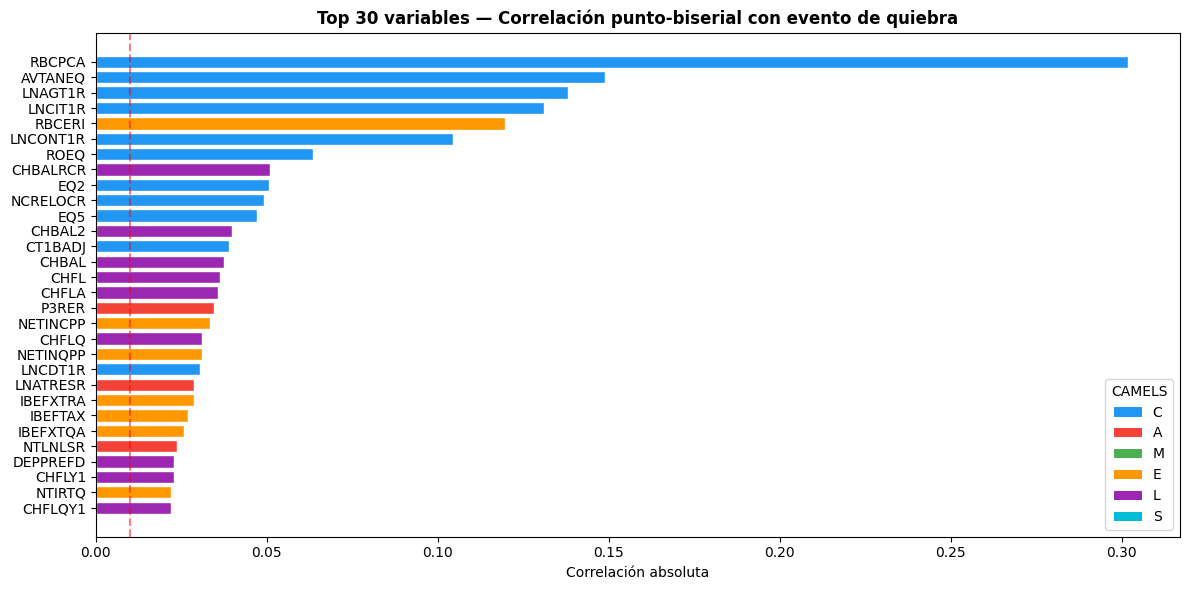

In [25]:
# Top 20 variables por correlación con failures
df_corr_plot = df_corr.head(30).copy()
df_corr_plot = df_corr_plot.merge(
    df_selected[['variable', 'camels']], on='variable', how='left'
)

color_map = {'C': '#2196F3', 'A': '#F44336', 'M': '#4CAF50',
             'E': '#FF9800', 'L': '#9C27B0', 'S': '#00BCD4'}
colors = [color_map.get(c, 'gray') for c in df_corr_plot['camels']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_corr_plot['variable'][::-1], 
               df_corr_plot['abs_correlation'][::-1],
               color=colors[::-1], edgecolor='white')
ax.set_title('Top 30 variables — Correlación punto-biserial con evento de quiebra',
             fontweight='bold')
ax.set_xlabel('Correlación absoluta')
ax.axvline(0.01, color='red', linestyle='--', alpha=0.5, label='Umbral seleccionado (0.01)')
ax.legend()

# Leyenda de componentes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, title='CAMELS', loc='lower right')

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'fe_correlation_ranking.png', dpi=150)
plt.show()

In [26]:
# 3 — Enriquecer con info CAMELS y guardar
df_selected = pd.read_csv(project_root / "docs" / "camels_selected.csv")
df_corr = df_corr.merge(
    df_selected[['variable', 'source', 'camels', 'description']], 
    on='variable', 
    how='left'
)

# Guardar
df_corr.to_csv(project_root / "docs" / "camels_failure_correlation.csv", index=False)
print(f"Guardado: camels_failure_correlation.csv")

# Resumen por componente CAMELS con failure
print(f"\nCorrelación media por componente CAMELS:")
print(df_corr.groupby('camels')['abs_correlation'].agg(['mean','max','count']).sort_values('mean', ascending=False))

Guardado: camels_failure_correlation.csv

Correlación media por componente CAMELS:
            mean     max  count
camels                         
C       0.024912  0.3020     51
E       0.009040  0.1197     94
L       0.008998  0.0508     65
A       0.006826  0.0345     62
M       0.005160  0.0199     40
S       0.003267  0.0158     83


`RBCPCA` con correlación 0.302 es la variable más discriminativa, esta variable es básicamente la clasificación regulatoria de capitalización del banco. Los bancos que van a quebrar tienen peor categoría regulatoria de capital trimestres antes.

El componente `C` (`Capital`) tiene la mayor correlación media (0.025) y el mayor máximo (0.302), lo que nos confirma que la adecuación de capital es el predictor más potente de quiebra, exactamente lo que predice la teoría `CAMELS`.

Variables con `p-value` alto como `EQ2`, `EQ5`, `CT1BADJ`, no son estadísticamente significativas.

El análisis de correlación `punto-biserial` con el evento de quiebra confirma la relevancia del componente `C` (`Capital`) como principal predictor, con `RBCPCA` obteniendo la correlación más alta (r=0.302, p<0.001). El componente `S` (`Sensitivity`) presenta la menor correlación media, consistente con el bajo nivel de actividad en derivados de la banca comunitaria americana en el periodo analizado.

Ahora hacemos un estudio del `p-value`. El `p-value` nos dice si la correlación observada es estadísticamente significativa o podría ser producto del azar. Con 206.129 observaciones casi cualquier correlación será significativa, ya que el test tiene muchísima potencia estadística. Pero hay variables donde hemos calculado la sobre un subconjunto pequeño de observaciones (las que no tienen NaN) y ahí el `p-value` sí discrimina.

Con 103 positivos sobre 206.129 observaciones, una correlación de 0.04 ya sale significativa simplemente por el tamaño muestral. El p-value aquí no es el criterio más útil para seleccionar variables.
Lo que sí tiene sentido hacer es un umbral de correlación mínima, por ejemplo eliminar variables con correlación absoluta <0.01, que son variables que prácticamente no discriminan entre bancos sanos y fallidos independientemente del `p-value`.

In [27]:
# Ver cuántas variables quedan con distintos umbrales de correlación
for threshold in [0.01, 0.02, 0.03, 0.05]:
    n = (df_corr['abs_correlation'] >= threshold).sum()
    print(f"Correlación >= {threshold}: {n} variables")

Correlación >= 0.01: 98 variables
Correlación >= 0.02: 36 variables
Correlación >= 0.03: 21 variables
Correlación >= 0.05: 9 variables


Con solo 103 positivos en 206k observaciones, el umbral de correlación tiene que ser bajo (menos que el tipico de 0.05) ya que exigir demasiado eliminaría variables que sí son relevantes teóricamente pero cuya señal estadística es débil por el extremo desbalanceo. Viendo los resultados obtenidos un umbral de 0.05 tipico nos deja solo 9 variables (de 409 posibles), lo cual nos haria perder demasiada información que aunque teoricamente no es relevante si que puede serlo en la practica. Por tanto tomamos un umbral de 0.01, lo cual nos deja 98 variables (con correlación ≥0.01) que es un subconjunto manejable y estadísticamente justificable. Además coincide bien con la literatura, ya que con tasas de quiebra tan bajas post-2016, correlaciones de 0.01-0.05 son normales y esperadas, es decir umbrales más estrictos eliminarían variables con relevancia teórica `CAMELS` demostrada pero con señal estadística débil por la baja tasa de quiebras en el periodo 2016-2025.

In [28]:
# Selección final — correlación >= 0.01
final_vars = df_corr[df_corr['abs_correlation'] >= 0.01]['variable'].tolist()
print(f"Variables finales seleccionadas: {len(final_vars)}")

# Ver distribución por componente CAMELS
df_corr_final = df_corr[df_corr['abs_correlation'] >= 0.01].copy()


print(f"\nDistribución por componente CAMELS:")
print(df_corr_final.groupby('camels')['abs_correlation']
      .agg(['mean','max','count'])
      .sort_values('mean', ascending=False))

# Guardar selección final
df_corr_final.to_csv(project_root / "docs" / "camels_final_selection.csv", index=False)
print(f"Guardado: camels_final_selection.csv")

Variables finales seleccionadas: 98

Distribución por componente CAMELS:
            mean     max  count
camels                         
C       0.063911  0.3020     19
L       0.023239  0.0508     18
E       0.019967  0.1197     33
A       0.017493  0.0345     15
M       0.013520  0.0199      5
S       0.013350  0.0158      8
Guardado: camels_final_selection.csv


Finalmente tenemos los siguientes documentos de claves `CAMEL` para nuestro pipeline
```p
camels_mapping.csv              ← mapeo automático CAMELS de todas las variables
camels_selected.csv             ← 409 variables tras limpieza y correlación >0.95
camels_failure_correlation.csv  ← correlaciones punto-biserial de las 401 variables
camels_final_selection.csv      ← 98 variables finales seleccionadas para el pipeline
``` 

El proceso completo de ingeniería de características ha reducido el espacio de variables de __4.721 columnas raw__ a __98 variables finales__, manteniendo únicamente aquellas con justificación teórica (`CAMELS`) y poder discriminativo empírico (_correlación con failures_).

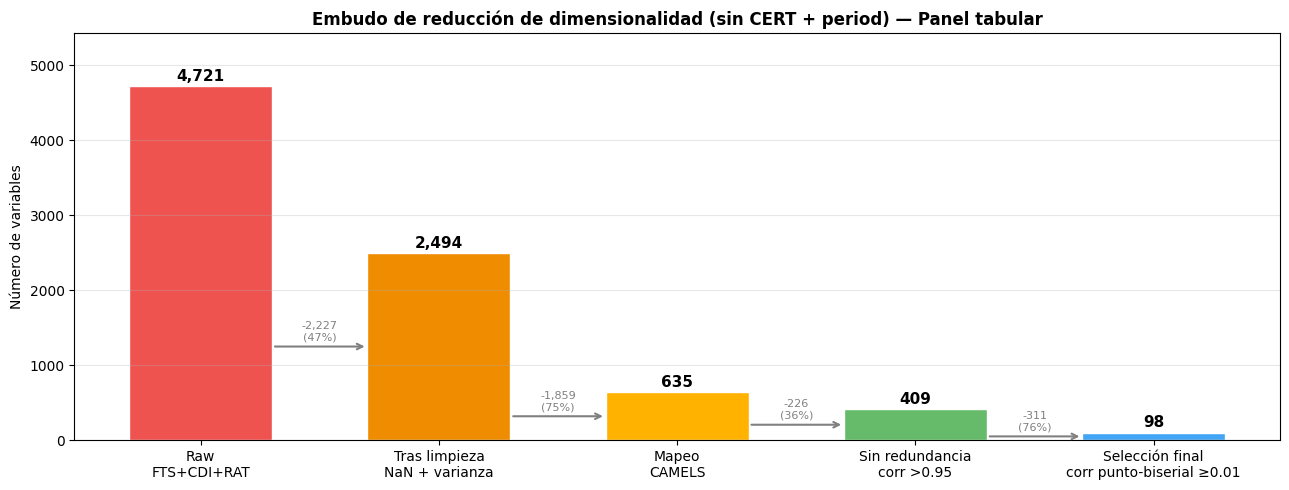

In [29]:
# Visualización del embudo de reducción
import matplotlib.patches as mpatches

etapas = [
    ('Raw\nFTS+CDI+RAT', 4721, '#ef5350'),
    ('Tras limpieza\nNaN + varianza', 2494, '#ef8c00'),
    ('Mapeo\nCAMELS', 635, '#ffb300'),
    ('Sin redundancia\ncorr >0.95', 409, '#66bb6a'),
    ('Selección final\ncorr punto-biserial ≥0.01', 98, '#42a5f5'),
]

fig, ax = plt.subplots(figsize=(13, 5))

x_pos = range(len(etapas))
valores = [e[1] for e in etapas]   
labels = [e[0] for e in etapas]
colors = [e[2] for e in etapas]    

bars = ax.bar(x_pos, valores, color=colors, edgecolor='white', width=0.6)

# Valores sobre las barras
for i, (bar, val) in enumerate(zip(bars, valores)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Flechas de reducción entre barras
for i in range(len(etapas) - 1):
    reduccion = valores[i] - valores[i+1]
    pct = reduccion / valores[i] * 100
    ax.annotate('', xy=(i+1-0.3, valores[i+1]/2), 
                xytext=(i+0.3, valores[i+1]/2),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(i+0.5, valores[i+1]/2 + 50, f'-{reduccion:,}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=8, color='gray')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Número de variables')
ax.set_title('Embudo de reducción de dimensionalidad (sin CERT + period) — Panel tabular',
             fontweight='bold', fontsize=12)
ax.set_ylim(0, max(valores) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'fe_reduction_funnel.png', dpi=150)
plt.show()

Aunque con las 409 caracteristicas que teniamos antes de implemetar los `failures` mediante la correlacion `punto-biserial` no colapsaba `TabPFN` (límite 2.000). Tenemos que el numero final de `98` es mejor por las siguientes razones: Con 103 positivos sobre las 206k observaciones, tener menos `features` reduce el riesgo de `overfitting` ya que el modelo no puede apoyarse en variables ruidosas.La metrica de interpretabilidad `SHAP` con 98 variables es mucho más eficaz que con 409, ya que sino el gráfico de importancias sería ilegible y pcoo explicativo.

Este proceso de reducción de caracteristicas en sí es un resultado metodológico ya que se demuestra que de miles de variables regulatorias bancarias, solo 98 tienen poder discriminativo real para predecir quiebras. Finalmete creamos el panel tabular final, que contiene las 98 variables financieras seleccionadas mediante `CAMELS`y `Failures` como criterio de selección adiccional.

In [30]:
# Panel tabular final con las 98 variables seleccionadas
panel_tabular_final = pd.read_parquet(PROCESSED_DIR / "panel_tabular.parquet")

# Filtrar solo las 98 variables finales + identificadores
id_cols = ['CERT', 'period']
cols_to_keep = id_cols + [c for c in final_vars if c in panel_tabular_final.columns]

panel_tabular_final = panel_tabular_final[cols_to_keep]
print(f"Panel tabular final: {panel_tabular_final.shape}")

panel_tabular_final.to_parquet(PROCESSED_DIR / "panel_tabular_camels98.parquet", index=False)
print(f"Guardado: panel_tabular_camels98.parquet")

Panel tabular final: (206129, 100)
Guardado: panel_tabular_camels98.parquet


De esta forma ahora tenemos tres paneles finales que serviran como ingesta de datos procesada para nuestro modelo hibrido de `ML` (todos almacenados en el contenedor de datos del disco duro `D:`)

1. `panel_tabular_camels98.parquet`: (206.129 × 100)  features financieras `CAMELS 98 variables + CERT + period` el cual transformaremos a un panel tabular temporal para `TabPFN`.

2. `panel_tabular_labeled.parquet`: (206.129 × 3)  target supervisado `CERT + period + failed`. Label supervisado para entrenamiento y validación. 

3. `panel_nodos.parquet `: (219.576 × 23)   features estructurales de identidad, geografía, holding, eventos `MERG`. Define nodos y atributos del grafo dinámico temporal.

__Nota:__  En el flujo del pipeline, `panel_tabular_camels98` no alimenta directamente a `T-GCN`. Primero tenemos que transformar el panel tabular creado y dotarlo de caracteristicas temporales donde `TabPFN` procesa este panel y produce _embeddings_ $e_{tem} \in \mathbb{R}^d$ que son los _embeddings_ que `T-GCN` recibe como features de nodo `X_t` en cada periodo `t`.